In [9]:
import jax
import jax.numpy as jnp
import numpy as np
import scipy.io as sio
from numpy.distutils.command import config

jax.config.update("jax_enable_x64", True)

data = sio.loadmat('KalmanDecoder.mat')

In [10]:
X_train = jnp.array(data['X_train'])
R_train = jnp.array(data['R_train'])
X_test = jnp.array(data['X_test'])
R_test = jnp.array(data['R_test'])
x_0 = jnp.array(data['x_0'])
P_0 = jnp.array(data['P_0'])  

print(f"X_train shape: {X_train.shape}")
print(f"R_train shape: {R_train.shape}")
print(f"T_train = {X_train.shape[1]} time steps")

X_train shape: (5, 8000)
R_train shape: (113, 8000)
T_train = 8000 time steps


Now we need to  calculate the parameters outside of the Kalman filter loop, in particular we need H, A, W and Q

In [11]:
def compute_H(R,X):
     XXT = X @ X.T
     XXT_inv = jnp.linalg.pinv(XXT)
     RXT= R @ X.T
     H = RXT @ XXT_inv
     return H

def compute_Q(R,X, H):
     T = X.shape[1]
     res = R - H @ X
     Q = (res @ res.T)/T
     return Q

def compute_A(X):
     X1 = X[:, :-1]
     X2 = X[:, 1:]
     X1X1T = X1 @ X1.T
     X1X1T_inv = jnp.linalg.pinv(X1X1T)
     A = (X2 @ X1.T) @ X1X1T_inv
     return A

def compute_W(X, A):
     T = X.shape[1]
     X1 = X[:, :-1]
     X2 = X[:, 1:]

     res = X2 - A @ X1
     W = (res @ res.T)/(T -1)
     return W


In [12]:
#chceking if everything is wokring out and if they have the predicted shapes
H = compute_H(R_train, X_train)
print(f"H shape: {H.shape}")

Q = compute_Q(R_train, X_train, H)
print(f"Q shape: {Q.shape}")

A = compute_A(X_train)
print(f"A shape: {A.shape}")

W = compute_W(X_train, A)
print(f"W shape: {W.shape}")


H shape: (113, 5)
Q shape: (113, 113)
A shape: (5, 5)
W shape: (5, 5)


Now we can start implmeenting the kalman filter, since we want to track some things for later in Q1-Q4, we need to already do a nice strructure

In [13]:
from dataclasses import dataclass, field
from typing import Dict, Tuple
import matplotlib.pyplot as plt

@dataclass
class KalmanConfig:
    """Configuration paramenter to keep track of progress and variables"""
    name: str
    #p0 and x0 exernal so i can modify them better later
    x_0: jnp.ndarray
    P_0: jnp.ndarray
    Q_scale: float = 1.0  # for Q4
    description: str = ""

@dataclass
class KalmanResult:
     """Store ressults for only one run"""
     name: str
     x_history: jnp.ndarray
     K_history: jnp.ndarray
     P_history: jnp.ndarray
     config: KalmanConfig

def KalmanFilter(A, H, W, Q, R_test, config):
     #apply scale to Q
     Q = Q * config.Q_scale

     #initialize all the other values, make sure x_0 is the correct shape
     T = R_test.shape[1]  # Number of time steps
     n_states = A.shape[0]
     n_neurons = H.shape[0]
     x = config.x_0.reshape(n_states, 1)
     P = config.P_0

     #prepping storage arrays in the right shapes
     x_history = jnp.zeros((n_states, T))
     K_history = jnp.zeros((T, n_states, n_neurons))
     P_history = jnp.zeros((T, n_states, n_states))


     #ACTUAL FILTER CODE
     for t in range(T):
          #first step: Prediction
          x_prior = A @ x
          C = A @ P @ A.T + W

          #second step: update
          K = C @ H.T @ jnp.linalg.pinv(H @ C @ H.T + Q)
          r_t = R_test[:, t:t+1]
          x = x_prior + K @ (r_t - H @ x_prior)
          P = (jnp.eye(n_states) - K @ H ) @ C

          x_history = x_history.at[:, t].set(x.flatten())
          K_history = K_history.at[t].set(K)
          P_history = P_history.at[t].set(P)

     return KalmanResult(
               name=config.name,
               x_history=x_history,
               K_history=K_history,
               P_history=P_history,
               config=config
          )


**Question 1:** Using the above equations, decode the actual kinematics (X_test) from the neural
firing observations (R_test). First you should use the training variables to determine the
system dynamics (i.e., use X_train and R_train). Then iterate over each time point of the test
set, with the final ‘decoded’ kinematic variables for that time point corresponding to the a posteriori
estimate. Make sure to save these values, so that you can assess how your decoded
kinematics matches up with reality (i.e., X_test). Use R2 to assess the goodness of fit of your
decoder. What was your R2 for each kinematic variable? Plot the decoding results for 100
time-steps in the format of slide 12 (lecture pdf).

x position: R² = 0.8915
y position: R² = 0.9097
x velocity: R² = 0.6818
y velocity: R² = 0.6308


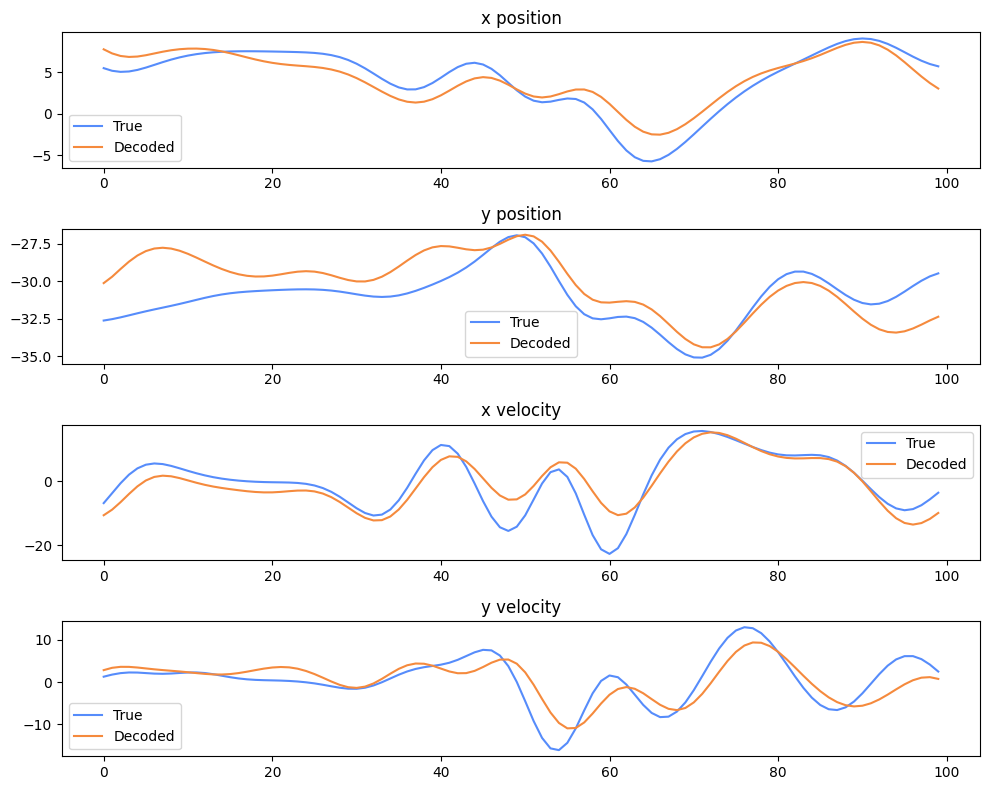

In [17]:
config = KalmanConfig(name="baseline", x_0=x_0, P_0=P_0)
result = KalmanFilter(A, H, W, Q, R_test, config)


decoded = result.x_history[1:, :] # ignore bias row
true = X_test[1:, :]

# R2
def compute_r2(y_true, y_pred):
    return 1 - jnp.sum((y_true - y_pred)**2) / jnp.sum((y_true - jnp.mean(y_true))**2)

labels = ["x position", "y position", "x velocity", "y velocity"]
r2_scores = [compute_r2(true[i], decoded[i]) for i in range(4)]

for label, r2 in zip(labels, r2_scores):
    print(f"{label}: R² = {r2:.4f}") #What was your R2 for each kinematic variable?

# plottings
import matplotlib.pyplot as plt

T_plot = 100
plt.figure(figsize=(10, 8))

for i in range(4):
    plt.subplot(4, 1, i+1)
    plt.plot(true[i, :T_plot], label="True")
    plt.plot(decoded[i, :T_plot], label="Decoded")
    plt.title(labels[i])
    plt.legend()

plt.tight_layout()
plt.show()

**Question 2:** The values of the Kalman gain evolve over time but eventually stabilizes when
the uncertainty of the estimates becomes low. Approximately how many time steps does it
take for each to stabilize? Plot the Kalman gain for the first 100 or so time steps (as in slide
20 of the lecture pdf). You’ll notice that for some kinematic variables the Kalman gain is positive
while others it is negative. Please provide a functional explanation of this fact (i.e., Why
would this be the case?).
Note: There is one Kalman gain for every neuron-kinematics pair (i.e., there are 5x113 of
them!). To get a better grasp on its evolution, take the mean Kalman gain across neurons.
This will give you one overall Kalman gain per four kinematic variable (ignore the baseline),
which you can plot.

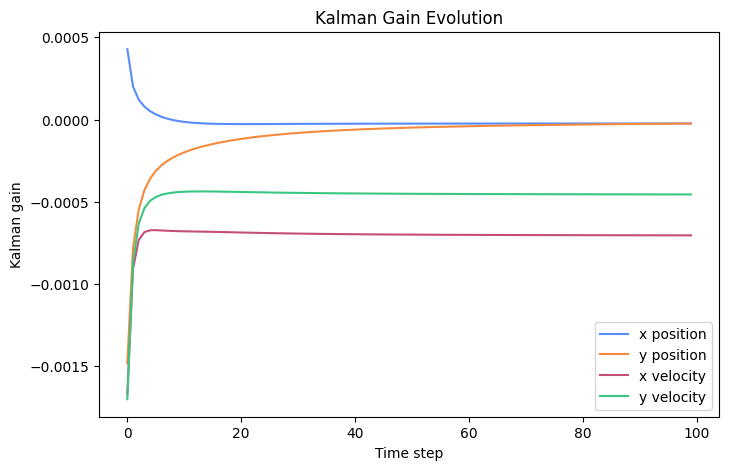

In [18]:
T_plot = 100
labels = ["x position", "y position", "x velocity", "y velocity"]

plt.figure(figsize=(8, 5))

#how much did i trus the neurons over time for that specific variable
for i in range(4):
    plt.plot(K_mean[:T_plot, i], label=labels[i])

plt.xlabel("Time step")
plt.ylabel("Kalman gain")
plt.title("Kalman Gain Evolution")
plt.legend()
plt.show()

How many time steps to stabilize? It takes between 15 and 20 time steps. The reason why it converges is because while in the beginning we have a high rate of uncertainty with the constant updates and the progressive learning, that values goes down until updates dont change their values much anymore, which leads to convergence. As for why some of the K values are positive and some negative, it represents the relationship between preferred direction of a neuron (how much their firing increases for a specific direction).

**Question 3:** Let’s explore how the initialization choices affect decoding performance. Initialize
your decoder using four combinations of x_0 and P_0. Set the same value for each kinematic
variable.
(1) x_0 = 0, P_0 = 1000; note that these are the initial values I provided you in the mat file. (2)
x_0 = -100, P_0 = 1000; (3) x_0 = 0, P_0 = 0.01; and finally, (4) x_0 = -100, P_0 = 0.01.
What affect does each initialization pair have on immediate performance? Are some combinations
better/worse than others? For each of the four combinations, plot the decoding results
in the same format as in Question 1.

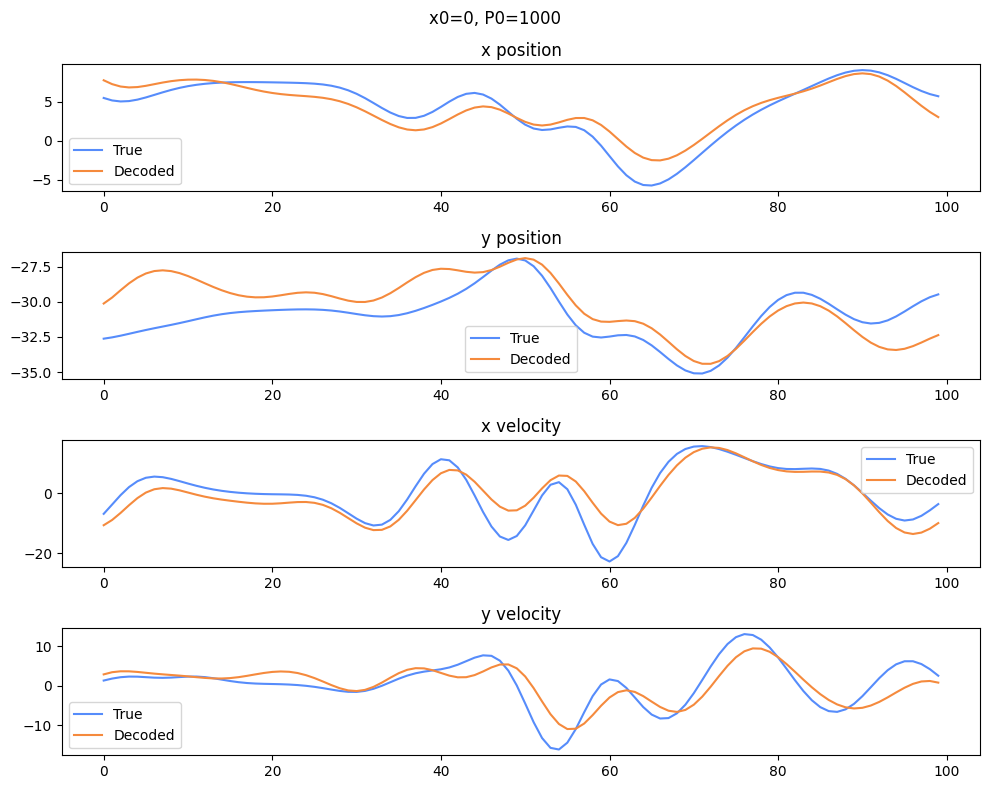

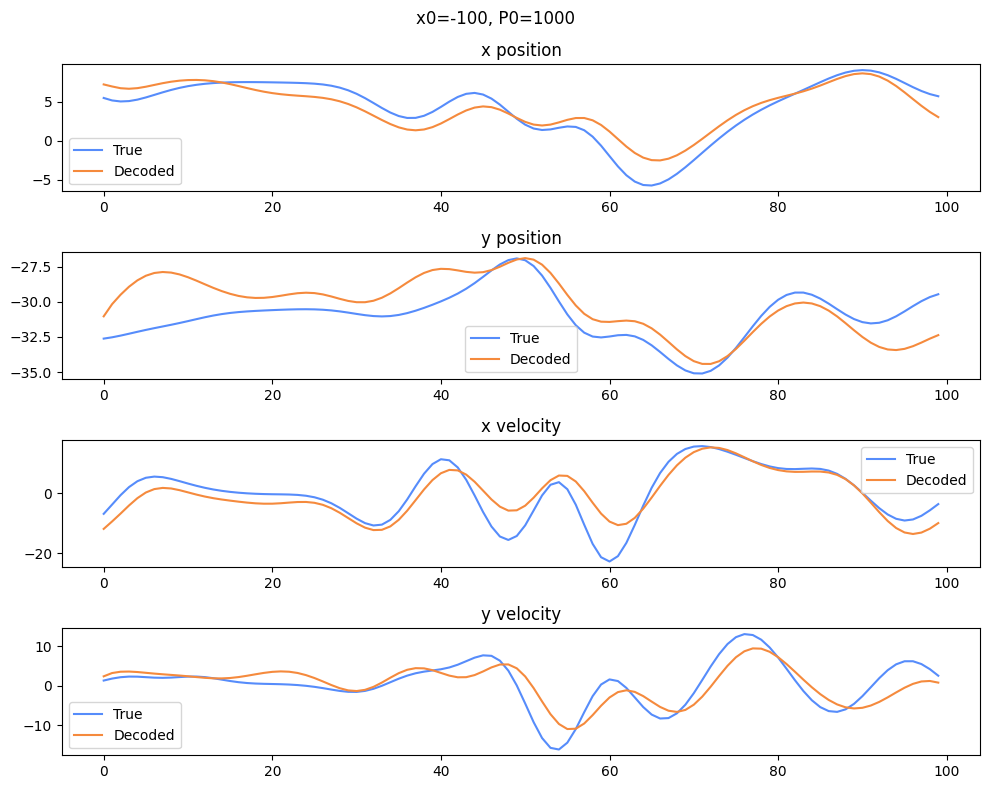

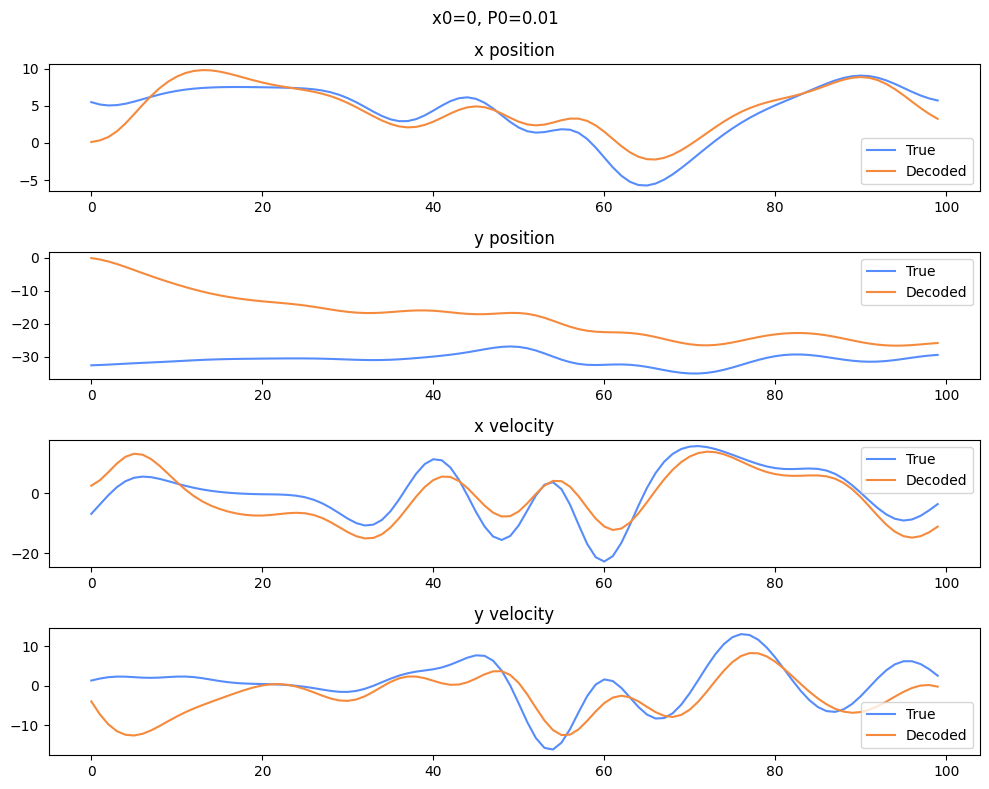

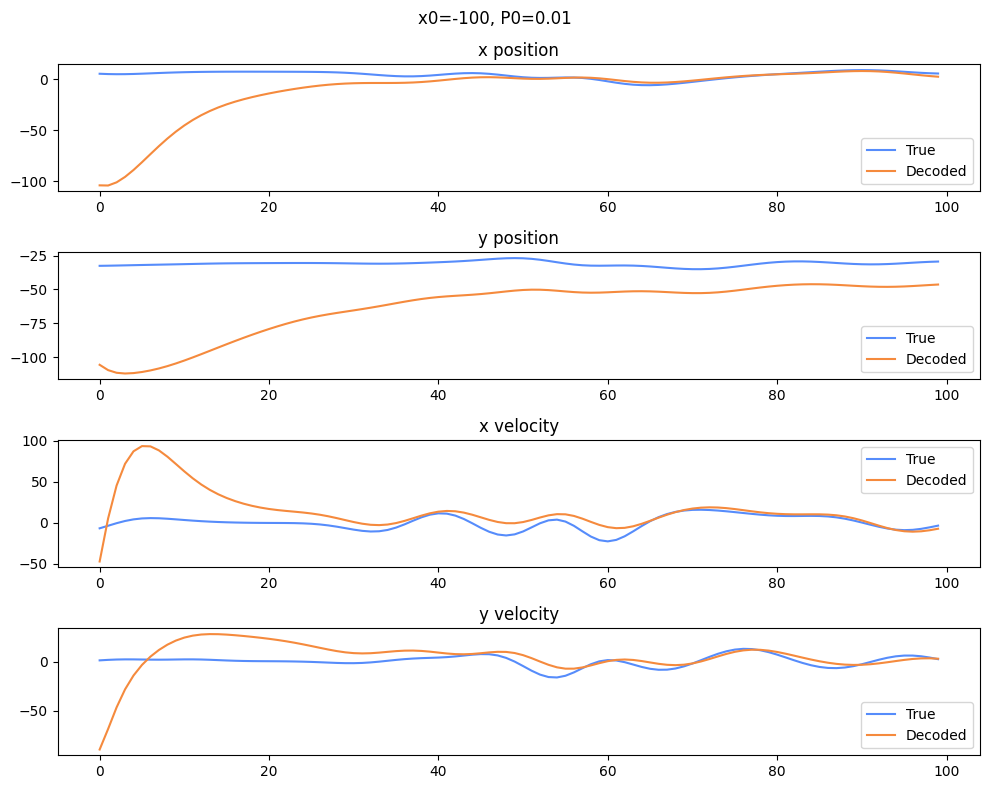

In [19]:
# functs to handle changing values more easily
def make_x0(val):
    return jnp.array([[1], [val], [val], [val], [val]])

def make_P0(val):
    return jnp.eye(5) * val

# configs
configs = [
    KalmanConfig("x0=0, P0=1000", make_x0(0), make_P0(1000)),
    KalmanConfig("x0=-100, P0=1000", make_x0(-100), make_P0(1000)),
    KalmanConfig("x0=0, P0=0.01", make_x0(0), make_P0(0.01)),
    KalmanConfig("x0=-100, P0=0.01", make_x0(-100), make_P0(0.01)),
]

# run all
results = [KalmanFilter(A, H, W, Q, R_test, cfg) for cfg in configs]


true = X_test[1:, :]  # ignore bias
labels = ["x position", "y position", "x velocity", "y velocity"]

T_plot = 100

# plotss (need to be 4)
for result in results:
    decoded = result.x_history[1:, :]  # ignore bias

    plt.figure(figsize=(10, 8))
    plt.suptitle(result.name)

    for i in range(4):
        plt.subplot(4, 1, i+1)
        plt.plot(true[i, :T_plot], label="True")
        plt.plot(decoded[i, :T_plot], label="Decoded")
        plt.title(labels[i])
        plt.legend()

    plt.tight_layout()
    plt.show()